<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-297-Natural-Language-Processing/blob/main/sjsu_Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color: blue"> Week 2 Class Demo</span>

# 1. Word2Vec
## 1.1 Overview
Word2Vec holds significance in the field of Natural Language Processing (NLP). Rather than being a single algorithm, it represents a diverse range of model architectures and optimization techniques used for acquiring word embeddings from extensive datasets. These embeddings, learned through Word2Vec, have consistently demonstrated their effectiveness across various downstream NLP tasks. There are two primary methods for obtaining word representations.

1. **Continuous Bag-of-Words Mode:** : This model predicts the central word based on the context words that surround it. The context typically includes a few words that appear both before and after the current (central) word. This architecture is referred to as a "bag-of-words" model because it disregards the sequential order of words in the context.<br>
2. **Skip-Gram Mode**: In contrast, the skip-gram model predicts words that appear within a certain proximity before and after the current word in the same sentence. This model is particularly effective at capturing word associations and relationships. Below, you'll find an illustrative example of the skip-gram model in action.

**For our class demonstration, we will be focusing on the skip-gram model only.**

## 1.2 Setup


### 1.2.1. Install TensorFlow if not yet
**Please note**: You may encounter compatibility issues between TensorFlow and your Python version. If that happens, you may need to install versions that are known to work together *(check website document or ask ChatGPT. For example Python 3.12 is compatible with Tensorflow 2.20)*.
If you are using Google Colab, you usually don’t need to worry — Colab provides a preconfigured environment where Python and TensorFlow are already set up with compatible versions.

In [205]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: /usr/bin/python3
Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [206]:
#!pip install tensorflow==2.21.0

### 1.2.2 Testing of installation

In [207]:
import tensorflow as tf

# Check TensorFlow version
print(tf.__version__)

2.20.0


### 1.2.3 Other Setup

In [208]:
#!pip install scikit-learn
#!pip install matplotlib

In [209]:
import numpy as np
from sklearn.manifold import TSNE
from ast import literal_eval
import matplotlib.pyplot as plt
import re
import string

from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, concatenate
from tensorflow.keras.models import Model

In [210]:
!pip install tqdm
!pip install ipywidgets

In [211]:
from tqdm.notebook import tqdm

In [212]:
# Load the TensorBoard notebook extension
# %load_ext tensorboard

In [213]:
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

### 1.3 Self Word Tokenization
For a training corpus text:

> The king ruled the kingdom with an iron fist.

Tokenize the sentence:

In [214]:
words = "The king ruled the kingdom with an iron fist"
word_tokens = list(words.lower().split())
print(len(word_tokens))
print(word_tokens)

9
['the', 'king', 'ruled', 'the', 'kingdom', 'with', 'an', 'iron', 'fist']


1. Establish a dictionary to map each token to a unique integer index.
2. Construct a reverse dictionary to map each integer index back to its corresponding token.

In [215]:
vocab = {}  # empty dict
vocab['<pad>'] = 0  # add a padding token as the start

index = 1
for token in word_tokens:
  if token not in vocab:
    vocab[token] = index
    index += 1
vocab_size = len(vocab)
print("Vocabulary:", vocab)

inverse_vocab = {index: token for token, index in vocab.items()}
print("Inverse vocabulary:", inverse_vocab)

Vocabulary: {'<pad>': 0, 'the': 1, 'king': 2, 'ruled': 3, 'kingdom': 4, 'with': 5, 'an': 6, 'iron': 7, 'fist': 8}
Inverse vocabulary: {0: '<pad>', 1: 'the', 2: 'king', 3: 'ruled', 4: 'kingdom', 5: 'with', 6: 'an', 7: 'iron', 8: 'fist'}


Sentence Vector with id

In [216]:
vec_words = [vocab[word] for word in word_tokens]
print(vec_words)

[1, 2, 3, 1, 4, 5, 6, 7, 8]


### 1.4 Generate skip-gram for one sentence

The module **tf.keras.preprocessing.sequence** in TensorFlow Keras offers handy utilities that make it easier to prepare data for word2vec. Utilize the function `tf.keras.preprocessing.sequence.skipgrams` to create skip-gram pairs from example_sequence, using a specified window_size and tokens within the range [0, vocab_size).

It's important to note that in this instance, negative_samples is set to 0.

In [217]:
window_size = 2
skip_grams, _ = tf.keras.preprocessing.sequence.skipgrams(
    vec_words,
    vocabulary_size=vocab_size,
    window_size=window_size,
    negative_samples=0,
    seed=SEED
    )
print("The total pairs number is: ", len(skip_grams))
print(skip_grams)

The total pairs number is:  30
[[5, 6], [4, 1], [1, 3], [7, 6], [6, 5], [3, 2], [3, 1], [1, 5], [1, 4], [4, 5], [1, 2], [7, 5], [8, 7], [6, 4], [4, 6], [7, 8], [1, 3], [4, 3], [5, 4], [2, 1], [5, 1], [8, 6], [2, 1], [6, 8], [3, 1], [3, 4], [6, 7], [1, 2], [2, 3], [5, 7]]


In [218]:
skip_grams_sorted = sorted(skip_grams)
print(skip_grams_sorted)

[[1, 2], [1, 2], [1, 3], [1, 3], [1, 4], [1, 5], [2, 1], [2, 1], [2, 3], [3, 1], [3, 1], [3, 2], [3, 4], [4, 1], [4, 3], [4, 5], [4, 6], [5, 1], [5, 4], [5, 6], [5, 7], [6, 4], [6, 5], [6, 7], [6, 8], [7, 5], [7, 6], [7, 8], [8, 6], [8, 7]]


Compare the generated skip_grams with the original sentence

In [219]:
for center, outside in skip_grams_sorted[:10]:
  print(f"({center}, {outside}): ({inverse_vocab[center]}, {inverse_vocab[outside]})")

print(word_tokens)

(1, 2): (the, king)
(1, 2): (the, king)
(1, 3): (the, ruled)
(1, 3): (the, ruled)
(1, 4): (the, kingdom)
(1, 5): (the, with)
(2, 1): (king, the)
(2, 1): (king, the)
(2, 3): (king, ruled)
(3, 1): (ruled, the)
['the', 'king', 'ruled', 'the', 'kingdom', 'with', 'an', 'iron', 'fist']


### 1.5 Generate negative sampling for one sentence

In [220]:
# Get outside and center words for one positive skip-gram.
center_word, context_word = skip_grams[0]

# Set the number of negative samples per positive context.
num_ns = 4

context_class = tf.reshape(tf.constant(context_word, dtype="int64"), (1, 1))
print("context class:", context_class)

negative_sampling_candidates, _, _ = tf.random.log_uniform_candidate_sampler(
    true_classes=context_class,  # class that should be sampled as 'positive'
    num_true=1,  # each positive skip-gram has 1 positive context class
    num_sampled=num_ns,  # number of negative context words to sample
    unique=True,  # all the negative samples should be unique
    range_max=vocab_size,  # pick index of the samples from [0, vocab_size]
    seed=SEED,  # seed for reproducibility
    name="negative_sampling"  # name of this operation
)
print("negative_sampling_candidates:\n", negative_sampling_candidates)

print([inverse_vocab[index.numpy()] for index in negative_sampling_candidates])

context class: tf.Tensor([[6]], shape=(1, 1), dtype=int64)
negative_sampling_candidates:
 tf.Tensor([6 3 4 7], shape=(4,), dtype=int64)
['an', 'ruled', 'kingdom', 'iron']


### 1.6 Construct to one sample

In [221]:
# Reduce a dimension so you can use concatenation (in the next step).
squeezed_context_class = tf.squeeze(context_class, 1)

# Concatenate a positive context word with negative sampled words.
context = tf.concat([squeezed_context_class, negative_sampling_candidates], 0)

# Label the first context word as `1` (positive) followed by `num_ns` `0`s (negative).
label = tf.constant([1] + [0]*num_ns, dtype="int64")
center = center_word


print("center:", center)
print("context:", context)
print("label:", label)

center: 5
context: tf.Tensor([6 6 3 4 7], shape=(5,), dtype=int64)
label: tf.Tensor([1 0 0 0 0], shape=(5,), dtype=int64)


### 1.7 Construct all examples using similar method as above

In [222]:
path_to_file = "/content/nasa_corpus.txt"

with open(path_to_file) as f:
  lines = f.read().splitlines()
for line in lines[:20]:
  print(line)

print(len(lines))

NASA Space Exploration and Discovery

The National Aeronautics and Space Administration, commonly known as NASA, is the United States government agency responsible for the civilian space program and for aeronautics and space research. NASA was established in 1958 and has been at the forefront of space exploration, scientific research, and technological innovation for over six decades.

Space Exploration Missions

NASA has conducted numerous groundbreaking space missions that have expanded our understanding of the universe. The Apollo program successfully landed twelve astronauts on the Moon between 1969 and 1972, with Neil Armstrong being the first human to set foot on the lunar surface. These missions demonstrated the incredible capabilities of human space exploration and inspired generations of scientists and engineers.

The Space Shuttle program revolutionized space travel by providing reusable spacecraft for transporting cargo and astronauts to orbit. The shuttle missions enabled t

### 1.8 Build a TextVectorization layer to do vectorization from an input data file

In [223]:
text_ds = tf.data.TextLineDataset(path_to_file)

In [224]:
for item in text_ds.take(5):
    print(item)

tf.Tensor(b'NASA Space Exploration and Discovery', shape=(), dtype=string)
tf.Tensor(b'', shape=(), dtype=string)
tf.Tensor(b'The National Aeronautics and Space Administration, commonly known as NASA, is the United States government agency responsible for the civilian space program and for aeronautics and space research. NASA was established in 1958 and has been at the forefront of space exploration, scientific research, and technological innovation for over six decades.', shape=(), dtype=string)
tf.Tensor(b'', shape=(), dtype=string)
tf.Tensor(b'Space Exploration Missions', shape=(), dtype=string)


### 1.8.1 Pre-tokenization step
**One example after applying the following process_line funtion:**
`
"Under the queen's rule, the kingdom prospered."
`

After step-by-step transformation:

    Lowercase: "under the queen's rule, the kingdom prospered."
    Handle possessives: "under the queen 's rule, the kingdom prospered."
    Remove punctuation: "under the queen 's rule the kingdom prospered"

In [225]:
# Define a custom standardization function that converts text to lowercase and eliminates punctuation

def process_line(input_data):

  lowercase = tf.strings.lower(input_data)
  pattern = r"(\w+)'s"
  repl = r"\1 's"
  lowercase = tf.strings.regex_replace(lowercase, pattern, repl)

  return tf.strings.regex_replace(lowercase,
                                  '[%s]' % re.escape(string.punctuation), '')

# Define the vocabulary size and the number of words in a sequence.
vocab_size = 300
sequence_length = 10

#Employ the TextVectorization layer for normalizing, splitting, and converting strings to integer values. Configure the output_sequence_length
#to ensure uniform padding, across all samples, making their lengths consistent.

# The "vectorize_layer" will be used in the following calls
vectorize_layer = layers.TextVectorization(
    standardize=process_line,
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length)

In [226]:
vectorize_layer.adapt(text_ds.batch(10))

In [227]:
# Save the created vocabulary for reference.
inverse_vocab = vectorize_layer.get_vocabulary()

inverse_vocab_show = [str(t) for t in inverse_vocab]  # strip np.str_

# Neat, indexed printout
for i, tok in enumerate(inverse_vocab_show):
    print(f"{i:>3}  {tok}")

  0  
  1  [UNK]
  2  and
  3  the
  4  space
  5  nasa
  6  to
  7  of
  8  for
  9  in
 10  research
 11  exploration
 12  scientific
 13  s
 14  missions
 15  systems
 16  that
 17  data
 18  on
 19  earth
 20  astronauts
 21  science
 22  international
 23  human
 24  have
 25  from
 26  technologies
 27  spacecraft
 28  advanced
 29  with
 30  this
 31  these
 32  public
 33  life
 34  future
 35  understanding
 36  our
 37  innovation
 38  agency
 39  technology
 40  satellites
 41  mars
 42  enable
 43  climate
 44  universe
 45  through
 46  scientists
 47  propulsion
 48  programs
 49  station
 50  solar
 51  physics
 52  observation
 53  moon
 54  knowledge
 55  has
 56  experiments
 57  environments
 58  debris
 59  beyond
 60  autonomous
 61  training
 62  support
 63  study
 64  rovers
 65  reduce
 66  program
 67  planetary
 68  monitor
 69  iss
 70  is
 71  including
 72  images
 73  help
 74  fundamental
 75  environmental
 76  discovery
 77  develops
 78  complex
 79  

In [228]:
text_vector_ds = text_ds.batch(10).prefetch(AUTOTUNE).map(vectorize_layer).unbatch()

In [229]:
sequences = list(text_vector_ds.as_numpy_iterator())

In [230]:
for seq in sequences[:5]:
  print(f"{seq} => {[inverse_vocab[i] for i in seq]}")

[ 5  4 11  2 76  0  0  0  0  0] => [np.str_('nasa'), np.str_('space'), np.str_('exploration'), np.str_('and'), np.str_('discovery'), '', '', '', '', '']
[0 0 0 0 0 0 0 0 0 0] => ['', '', '', '', '', '', '', '', '', '']
[  3   1   1   2   4   1   1   1 162   5] => [np.str_('the'), '[UNK]', '[UNK]', np.str_('and'), np.str_('space'), '[UNK]', '[UNK]', '[UNK]', np.str_('as'), np.str_('nasa')]
[0 0 0 0 0 0 0 0 0 0] => ['', '', '', '', '', '', '', '', '', '']
[ 4 11 14  0  0  0  0  0  0  0] => [np.str_('space'), np.str_('exploration'), np.str_('missions'), '', '', '', '', '', '', '']


### 1.9 Generating the training set

In [231]:
#Creates skip-gram pairings with negative sampling from a sequence list, considering the window size, quantity of negative samples,
#and the size of the vocabulary.


def generate_training_data(sequences, window_size, num_ns, vocab_size, seed):
  # Elements of each training example are appended to these lists.
  centers, contexts, labels = [], [], []
  total_positive = 0
  # Build the sampling table for `vocab_size` tokens.  It generates a probability distribution for each word in the vocabulary.
  #This distribution is based on the word frequency raised to 3/4th power (as per the original Word2Vec paper).
  #This exponentiation of the frequency serves to moderate the difference in probabilities between high-frequency and low-frequency words.
  sampling_table = tf.keras.preprocessing.sequence.make_sampling_table(vocab_size)

  # Iterate over all sequences (sentences) in the dataset.

  for sequence in sequences:
    # Generate positive skip-gram pairs for a sequence (sentence).
    positive_skip_grams, _ = tf.keras.preprocessing.sequence.skipgrams(
          sequence,
          vocabulary_size=vocab_size,
          sampling_table=sampling_table,
          window_size=window_size,
          negative_samples=0,
          seed=seed
        )

    total_positive += len(positive_skip_grams)
    # Iterate over each positive skip-gram pair to produce training examples
    # iterate all positive skip grams, with a positive context word and negative samples.
    for center_word, context_word in positive_skip_grams:
      context_class = tf.expand_dims(
          tf.constant([context_word], dtype="int64"), 1)
      negative_sampling_candidates, _, _ = tf.random.log_uniform_candidate_sampler(
          true_classes=context_class,
          num_true=1,
          num_sampled=num_ns,
          unique=True,
          range_max=vocab_size,
          seed=seed,
          name="negative_sampling")

      # Build context and label vectors (for one target word)
      context = tf.concat([tf.squeeze(context_class,1), negative_sampling_candidates], 0)
      label = tf.constant([1] + [0]*num_ns, dtype="int64")

      # Append each element from the training example to global lists.
      centers.append(center_word)
      contexts.append(context)
      labels.append(label)

  print("Total positive pairs: ", total_positive)
  return centers, contexts, labels

In [232]:
centers, contexts, labels = generate_training_data(
    sequences=sequences,
    window_size=2,
    num_ns=4,
    vocab_size=vocab_size,
    seed=SEED)

centers = np.array(centers)
contexts = np.array(contexts)
labels = np.array(labels)

print(f"centers.shape: {centers.shape}")
print(f"contexts.shape: {contexts.shape}")
print(f"labels.shape: {labels.shape}")

Total positive pairs:  170
centers.shape: (170,)
contexts.shape: (170, 5)
labels.shape: (170, 5)


In [233]:
BATCH_SIZE = 10
BUFFER_SIZE = 100
dataset = tf.data.Dataset.from_tensor_slices(((centers, contexts), labels))
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
print(dataset)

<_BatchDataset element_spec=((TensorSpec(shape=(10,), dtype=tf.int64, name=None), TensorSpec(shape=(10, 5), dtype=tf.int64, name=None)), TensorSpec(shape=(10, 5), dtype=tf.int64, name=None))>


In [234]:
dataset = dataset.cache().prefetch(buffer_size=AUTOTUNE)
print(dataset)

<_PrefetchDataset element_spec=((TensorSpec(shape=(10,), dtype=tf.int64, name=None), TensorSpec(shape=(10, 5), dtype=tf.int64, name=None)), TensorSpec(shape=(10, 5), dtype=tf.int64, name=None))>


### 1.10 Build the model

In [235]:
class Word2Vec(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim):
    super(Word2Vec, self).__init__()
    self.center_embedding = layers.Embedding(vocab_size,
                                      embedding_dim,
                                      input_length=1,
                                      name="word2vec_embedding")
    self.context_embedding = layers.Embedding(vocab_size,
                                       embedding_dim)

  def call(self, pair):
    center, context = pair
    # center: (batch, )
    # context: (batch, context)
    if len(center.shape) == 2:
      center = tf.squeeze(center, axis=1)
    # center: (batch,)
    word_emb = self.center_embedding(center)
    # word_emb: (batch, embed)
    context_emb = self.context_embedding(context)
    # context_emb: (batch, context, embed), calculate the similarity using dot product
    logits = tf.einsum('be,bce->bc', word_emb, context_emb)
    print("word_emb shape: ", word_emb.shape)
    print("context_emb shape:", context_emb.shape)
    print("logits shape: ", logits.shape)
    #  (batch, context)
    return logits

In [236]:
embedding_dim = 128
word2vec = Word2Vec(vocab_size, embedding_dim)
word2vec.compile(optimizer='adam',
                 loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
                 metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [237]:
word2vec.fit(dataset, epochs=60)

Epoch 1/60
word_emb shape:  (10, 128)
context_emb shape: (10, 5, 128)
logits shape:  (10, 5)
word_emb shape:  (10, 128)
context_emb shape: (10, 5, 128)
logits shape:  (10, 5)
word_emb shape:  (10, 128)
context_emb shape: (10, 5, 128)
logits shape:  (10, 5)
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2235 - loss: 1.6089
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8235 - loss: 1.5891 
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9588 - loss: 1.5700
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9765 - loss: 1.5469
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9765 - loss: 1.5172
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9706 - loss: 1.4791
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9706 - loss: 1.4309
Epoch 8/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9706 - loss: 1.3718
Epoch 9/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9647 - loss: 1.30

In [238]:
weights = word2vec.get_layer('word2vec_embedding').get_weights()[0]
vocab = vectorize_layer.get_vocabulary()

print(weights.shape)
print("One embeddings: \n")
print(weights[3])

(300, 128)
One embeddings: 

[-0.00285633  0.02709171  0.01518838  0.04569889 -0.00734881 -0.04575274
 -0.04214091 -0.01093471 -0.00549085  0.04783993 -0.02754116 -0.03706515
 -0.01320101 -0.03307458  0.01134168  0.03632071 -0.04706677  0.0353401
  0.04977187 -0.01235367  0.01220144  0.04921353 -0.04863371  0.01384412
 -0.02003458 -0.03907484 -0.04039881 -0.04453378  0.02701535 -0.00990025
  0.03310006 -0.04559146  0.02450179 -0.03203233  0.04570747 -0.02669667
 -0.02443686 -0.01617792 -0.02807673 -0.04647081 -0.02961698 -0.02548013
  0.04316676 -0.01204921  0.04754913 -0.01818125 -0.0103857  -0.00757515
  0.04764989 -0.00119021  0.00547556  0.03173448  0.02532152  0.02462501
 -0.03011309 -0.0153725  -0.02949331 -0.0489037   0.04441324  0.04466511
  0.00923147 -0.00571346  0.00191277  0.02951613  0.02345493 -0.01547353
  0.02236769 -0.04461105 -0.00954497 -0.03995516  0.00304144 -0.0380589
 -0.04823858 -0.04073825 -0.02058022 -0.04205794 -0.02024098 -0.00036823
 -0.04977622  0.02171643

In [239]:
embedding_dict = { }
for index, word in enumerate(vocab):
    if index != 0:  # skip 0, it's padding.
        vec = weights[index]
        embedding_dict[word] = vec

In [240]:
print(len(embedding_dict))

299


In [241]:
words = ["space", "nasa", "research","exploration", "scientific", "missions", "earth", "astronauts"]
e_words = []

for word in words:
    if word in embedding_dict: # Check if the word exists in the dictionary
        e_words.append(embedding_dict[word])
    else:
        print(f"Warning: Word '{word}' not found in embedding_dict and will be skipped.")

In [242]:
e_words_np = np.array(e_words)

e_words_np.shape

(8, 128)

In [243]:
# Create tsne object which will reduce data to 2 dimensions
tsne = TSNE(n_components=2, perplexity=3)

In [244]:
e_words_2d = tsne.fit_transform(e_words_np)
e_words_2d.shape

(8, 2)

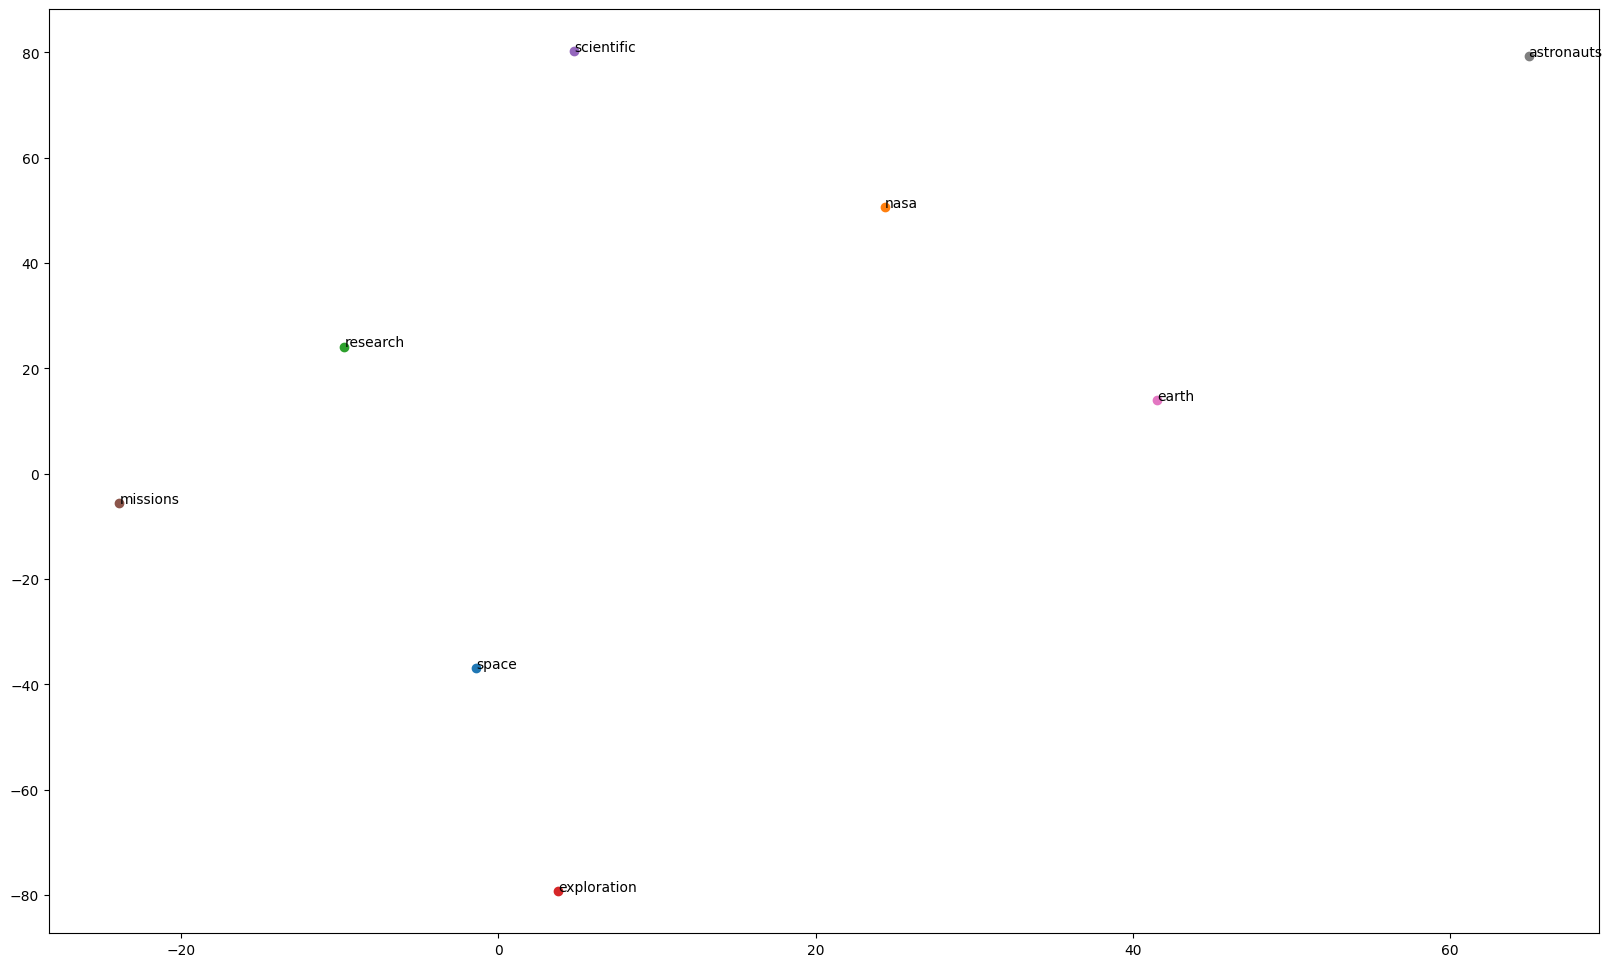

In [245]:
plt.figure(figsize=(20, 12))

for i in range (len(words)):
    plt.scatter(e_words_2d[i,0], e_words_2d[i,1])

# Add annotations
for i in range(len(words)):
    plt.annotate(words[i], (e_words_2d[i][0], e_words_2d[i][1]))

plt.show()